In [11]:
import numpy as np
import pandas as pd
import os
import warnings
for dirname, _, filenames in os.walk('/kaggle/input'):
  for filename in filenames:
    print(os.path.join(dirname, filename))

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV,cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC

from sklearn.feature_selection import SelectKBest,f_classif

from sklearn.metrics import(
     accuracy_score,
     confusion_matrix,
     classification_report,
     roc_auc_score
)

from xgboost import XGBClassifier


data=pd.read_csv('/content/diabetes.csv')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**Exploring and Understanding the Data**

In [18]:
data.shape
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Checking number of unique value in each column

In [19]:
dict = {}
for i in list(data.columns):
  dict[i] = data[i].value_counts().shape[0]
pd.DataFrame(dict, index = ['unique count']).transpose()

,unique count
Pregnancies,17
Glucose,136
BloodPressure,47
SkinThickness,51
Insulin,186
BMI,248
DiabetesPedigreeFunction,517
Age,52
Outcome,2


Statistics

In [21]:
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


Missing Values

In [22]:
data.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


EDA

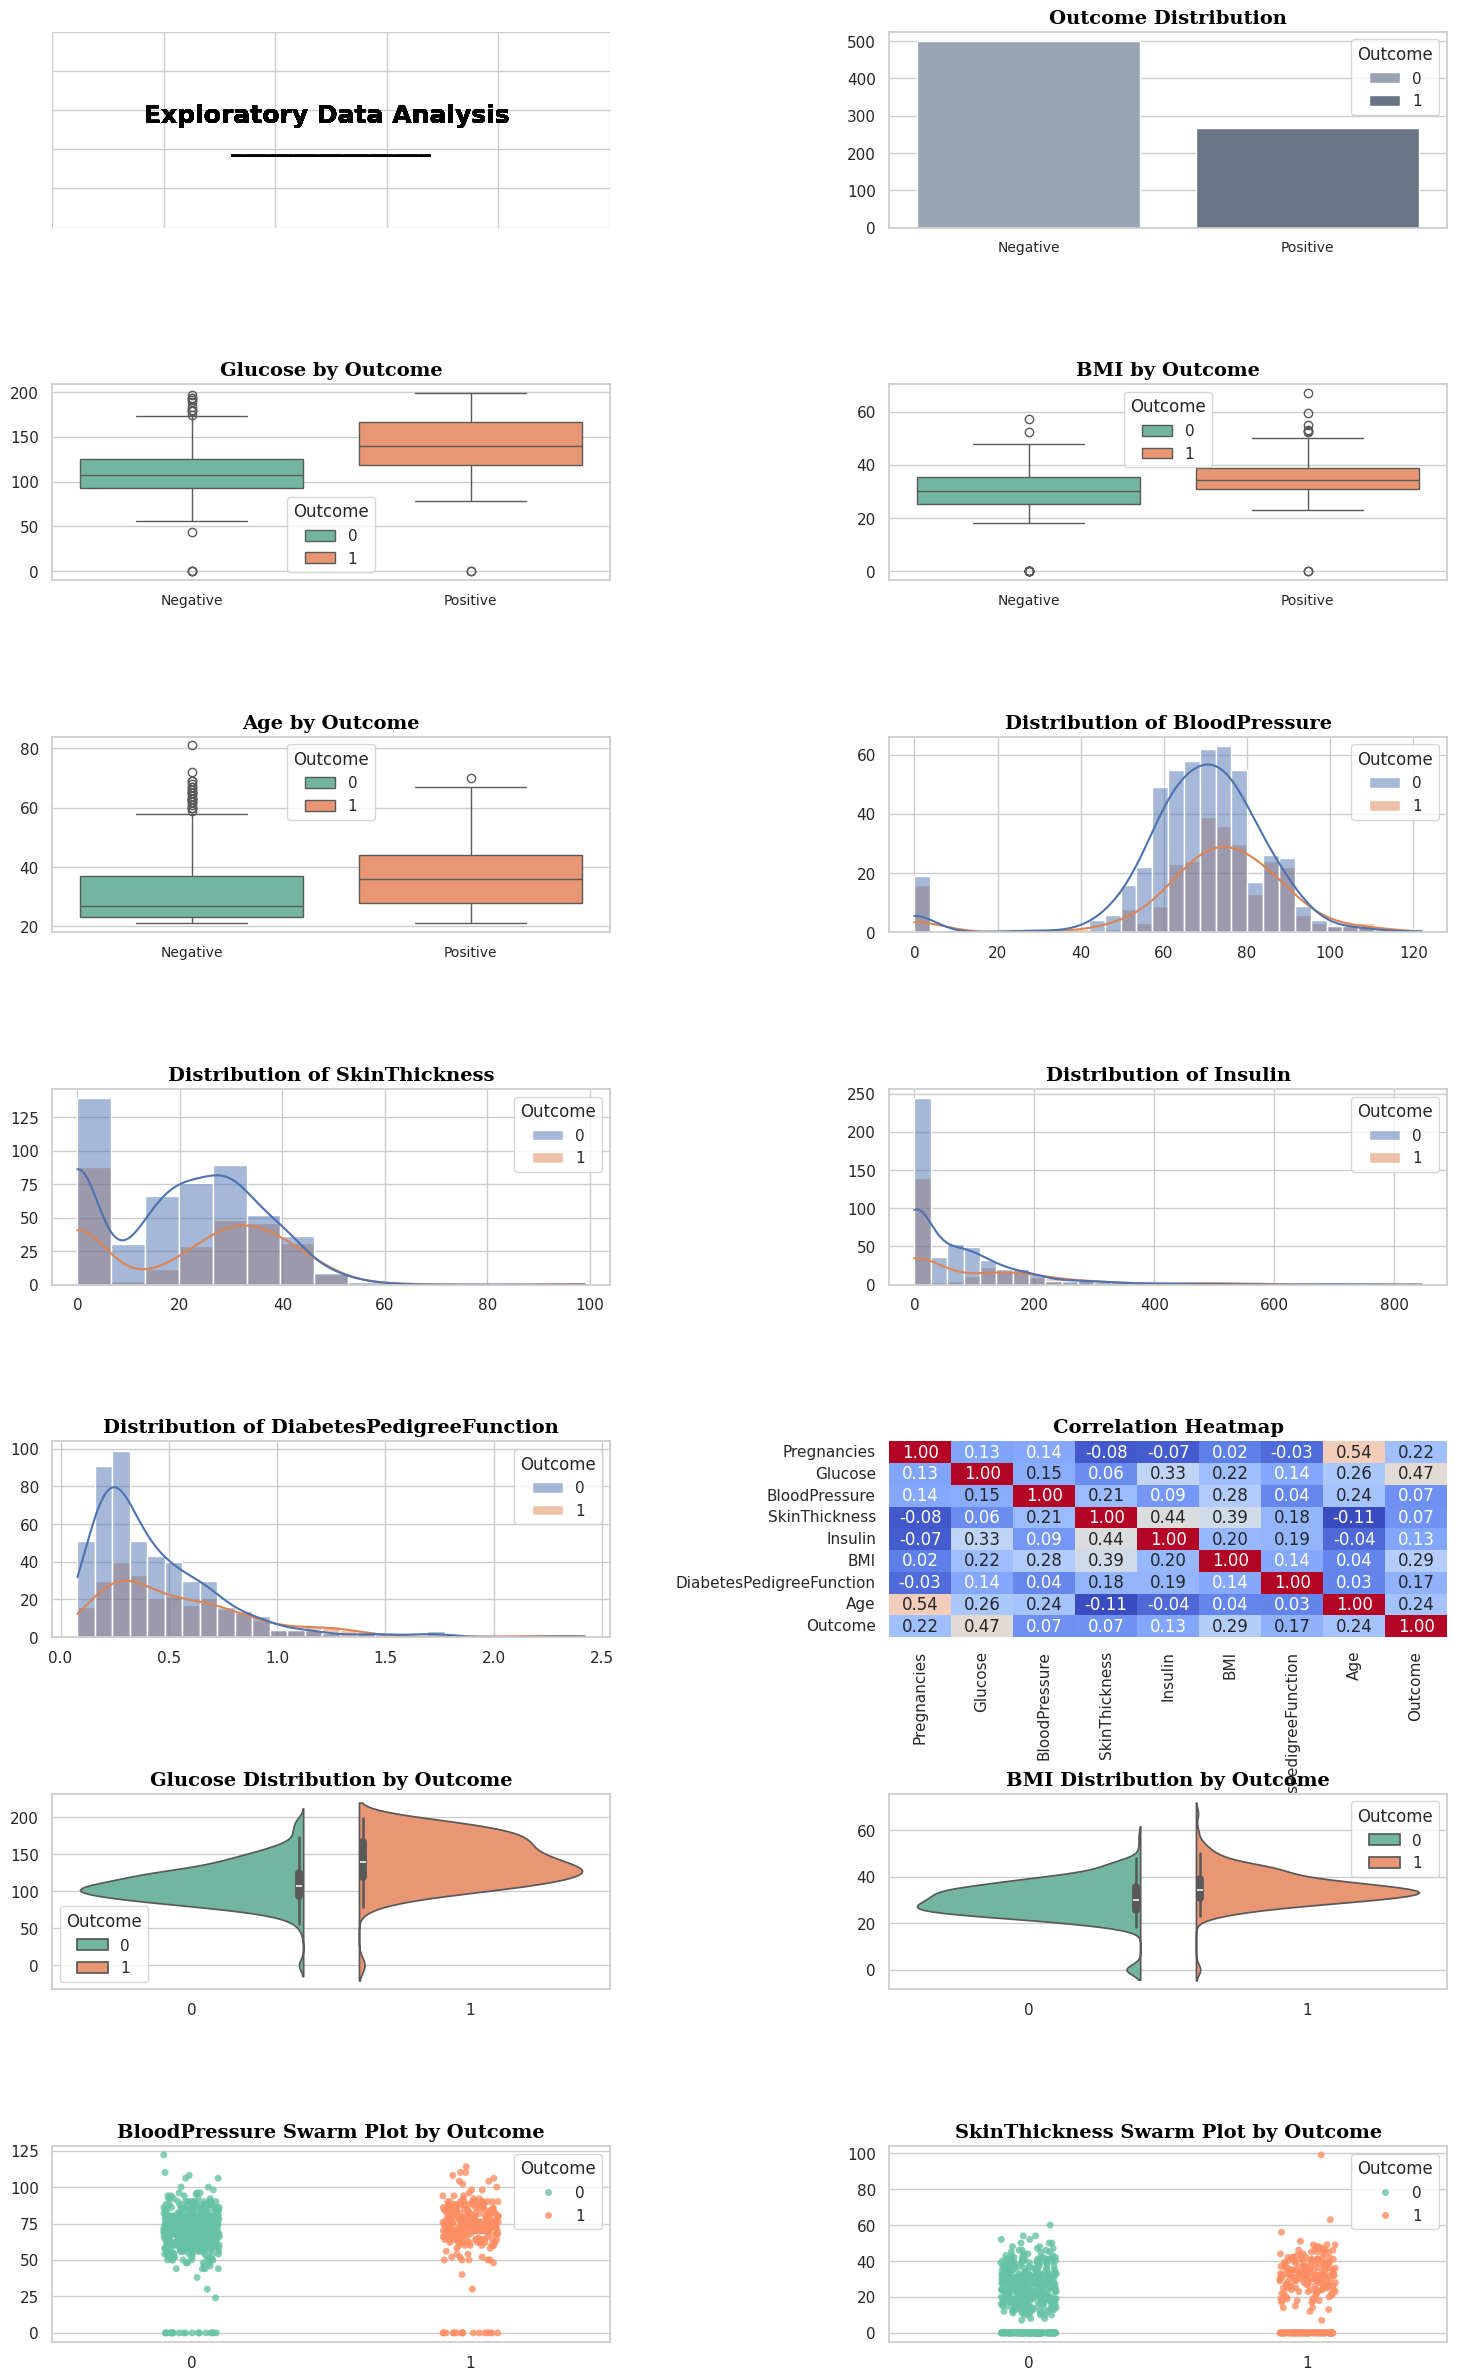

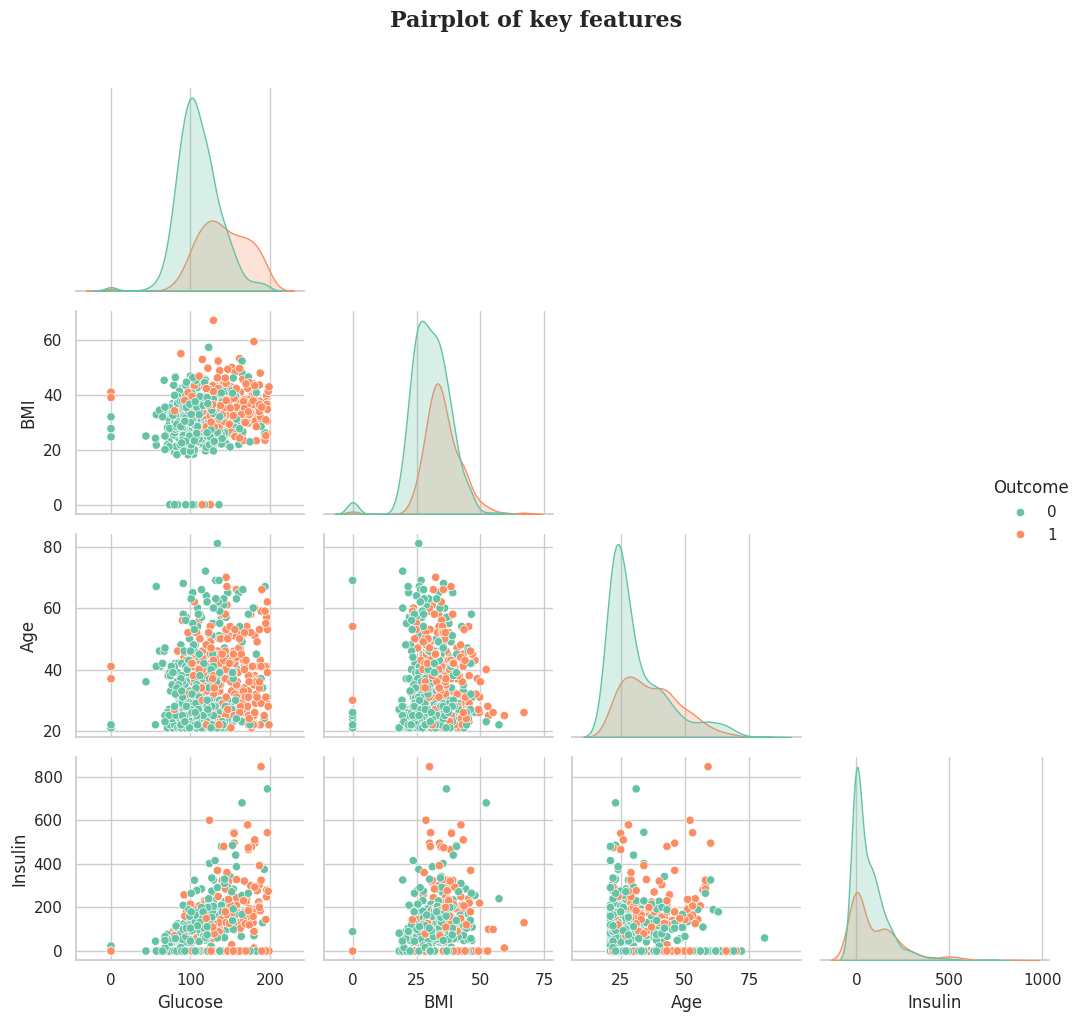

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data=pd.read_csv('/content/diabetes.csv')
data.replace([np.inf, -np.inf], np.nan, inplace=True)
background_color = "#f8fafc"
color_palette = ["#94a3b8","#64748b","#475569","#334155","1e293b"]

fig = plt.figure(figsize=(18,30))
gs = fig.add_gridspec(7,2)
gs.update(wspace=0.5, hspace=0.8)

axes = [fig.add_subplot(gs[i,j]) for i in range(7) for j in range(2)]
for ax in axes:
  axes[0].spines["bottom"].set_visible(False)
  axes[0].spines["left"].set_visible(False)
  axes[0].spines["top"].set_visible(False)
  axes[0].spines["right"].set_visible(False)
  axes[0].tick_params(left=False, bottom=False)
  axes[0].set_xticklabels([])
  axes[0].set_yticklabels([])
  axes[0].text(0.5, 0.5,
               'Exploratory Data Analysis \n________________',
               horizontalalignment='center',
               verticalalignment='center',
               fontsize=18, fontweight='bold',
               color="#000000")

#count plot for categorical feature 'Outcome'
color_palette_outcome = sns.color_palette(color_palette, n_colors=data['Outcome'].nunique())
sns.countplot(ax=axes[1], data=data, x='Outcome',hue='Outcome', palette=color_palette_outcome)
axes[1].set_title('Outcome Distribution', loc='center', fontsize=14, fontweight='bold', fontfamily="serif", color="#000000")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Negative','Positive'], fontsize=10)

#boxplots for numerical vs. categorical relationships
num_features = ['Glucose','BMI','Age']
boxplot_titles = ['Glucose by Outcome','BMI by Outcome','Age by Outcome']

for i,feature in enumerate(num_features):
  ax = axes[i+2]

  outcome_palette = sns.color_palette("Set2", n_colors=data['Outcome'].nunique())

  sns.boxplot(ax=ax, data=data, x='Outcome', y=feature, hue='Outcome',palette=outcome_palette)
  ax.set_title(boxplot_titles[i], loc='center', fontsize=14, fontweight='bold', fontfamily="serif", color="#000000")
  ax.set_xlabel("")
  ax.set_ylabel("")
  ax.set_xticks([0, 1])
  ax.set_xticklabels(['Negative','Positive'], fontsize=10)

#Distribution plots for numerical features
numerical_features= ['BloodPressure' , 'SkinThickness' , 'Insulin' , 'DiabetesPedigreeFunction']

for i,feature in enumerate(numerical_features):
      ax = axes[i+5]
      sns.histplot(ax=ax, data=data, x=feature,hue='Outcome', kde=True, color=color_palette[i% len(color_palette)])
      ax.set_title(f"Distribution of {feature}", loc='center', fontsize=14, fontweight='bold', fontfamily="serif", color="#000000")
      ax.set_xlabel("")
      ax.set_ylabel("")

#Pairplot for selected numerical features

outcome_palette = sns.color_palette("Set2", n_colors=data['Outcome'].nunique())
sns.pairplot(data=data, vars=['Glucose','BMI','Age','Insulin'],hue='Outcome',palette=outcome_palette, diag_kind="kde", corner=True)
plt.suptitle("Pairplot of key features",y=1.02, fontsize=16,fontweight="bold", fontfamily="serif")

#Heatmap of correlation matrix
corr_matrix = data.corr()
sns.heatmap(corr_matrix, ax=axes[9], annot=True, fmt='.2f', cmap='coolwarm', cbar=False)
axes[9].set_title('Correlation Heatmap', loc='center', fontsize=14, fontweight='bold', fontfamily="serif", color="#000000")

#Violin plots of detailed distributions by Outcome
violin_features = ['Glucose','BMI']

for i,feature in enumerate(violin_features):
      ax = axes[i+10]

      outcome_palette = sns.color_palette("Set2", n_colors=data['Outcome'].nunique())
      sns.violinplot(ax=ax, data=data, x='Outcome', y=feature,hue='Outcome', palette=outcome_palette, split=True)
      ax.set_title(f"{feature} Distribution by Outcome", loc='center', fontsize=14, fontweight='bold', fontfamily="serif", color="#000000")
      ax.set_xlabel("")
      ax.set_ylabel("")

#Swarm plots for finer analysismof distributions
swarm_features = ['BloodPressure','SkinThickness']

for i,feature in enumerate(swarm_features): # Changed `violin_features` to `swarm_features`
      ax = axes[i+12]

      outcome_palette = sns.color_palette("Set2", n_colors=data['Outcome'].nunique())
      sns.stripplot(ax=ax, data=data, x='Outcome', y=feature,hue='Outcome', palette=outcome_palette, alpha=0.8)
      ax.set_title(f"{feature} Swarm Plot by Outcome", loc='center', fontsize=14, fontweight='bold', fontfamily="serif", color="#000000")
      ax.set_xlabel("")
      ax.set_ylabel("")

#Adjust layout and show the plots
plt.tight_layout()
plt.show()

Data Modeling

In [24]:
from sklearn.model_selection import train_test_split

data_copy = data.copy()

X=data_copy.drop(["Outcome"],axis=1)
y=data_copy["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20, random_state=25)

Data preprocessing

In [25]:
def preprocess_data(data):
  zero_columns=['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

  #cloning the dataset to avoid modifying the original
  processed_data=data.copy()

  for col in zero_columns:
    processed_data[col] = processed_data[col].replace(0, np.nan)
  return processed_data

Prepare features and target

In [26]:
#separate features(X) & target variable(y)
def prepare_features(data):
  X = data.drop('Outcome', axis=1)
  y = data['Outcome']
  return X,y

Create a preprocessing pipeline

In [27]:
#pipeline that imputes missing values and scales the data
def create_preprocessing_pipeline():
    return Pipeline([
        ('imputer',SimpleImputer(strategy='median')),
        ('scaler', RobustScaler())
    ])

Define models to evaluate

In [46]:
#return a dictionary to ML models to evaluate
def create_models():
  return{
      'XGBoost': XGBClassifier(eval_metric='logloss'),
      'Random Forest': RandomForestClassifier(),
      'Logistic Regression': LogisticRegression(),
      'SVM': SVC(probability=True)
  }

Hyperparameter tuning

In [47]:
#hyperparameter tuning using GridSearchCV for specific models
def perform_grid_search(X_train,y_train):
    param_grid = {
        'XGBoost':{
            'learning_rate':[0.01, 0.1],
            'max_depth':[3,5],
            'n_estimators':[100,200]
        },
        'Random Forest':{
            'n_estimators':[100,200],
            'max_depth':[None, 10 ,20],
            'min_samples_split':[2,5]
        }
    }
    best_models={}
    for name, model in create_models().items():
      if name in param_grid:
        grid_search = GridSearchCV(
            model,
            param_grid[name],
            cv=5,
            scoring='roc_auc'
        )
        grid_search.fit(X_train, y_train)
        best_models[name] = grid_search.best_estimator_
        return best_models

Evaluate models

In [48]:
#using accuracy and ROC AUC scores
def evaluate_models(models, X_test, y_test):
  results= {}
  for name, model in models.items():
    y_pred = model.predict(X_test)
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    }
  return results

Create an ensemble model

In [49]:
#create a soft-voting ensemble classifier using best individual models
def create_voting_classifier(models):
  estimators = list(models.items())
  return VotingClassifier(
      estimators=estimators,
      voting='soft'
  )

def main():
  #preprocess the data
  processed_data = preprocess_data(data)

  #prepare features and target
  X,y = prepare_features(processed_data)

  #split data into training and testing sets
  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42
  )

  #Create and apply the preprocessing pipeline
  preprocessor = create_preprocessing_pipeline()
  X_train_processed = preprocessor.fit_transform(X_train)
  X_test_processed = preprocessor.transform(X_test)

  #perform hyperparameter tuning
  best_models = perform_grid_search(X_train_processed, y_train)

  #evaluate individual models
  model_results = evaluate_models(best_models, X_test_processed, y_test)

  #create and evaluate the ensemble model
  voting_classifier = create_voting_classifier(best_models)
  voting_classifier.fit(X_train_processed, y_train)

  ensemble_accuracy = accuracy_score(
      y_test, voting_classifier.predict(X_test_processed)
  )
  ensemble_roc_auc = roc_auc_score(
      y_test, voting_classifier.predict_proba(X_test_processed)[:, 1]
  )

  #print results
  print("Individual Model Results:")
  for name, metrics in model_results.items():
    print(f"{name}: {metrics}")
  print(f"\nEnsemble Accuracy: {ensemble_accuracy}")
  print(f"Ensemble ROC AUC: {ensemble_roc_auc}")

 #execute script
if __name__ == "__main__":
  main()

Individual Model Results:
XGBoost: {'Accuracy': 0.7272727272727273, 'ROC AUC': np.float64(0.8145087235996327)}

Ensemble Accuracy: 0.7272727272727273
Ensemble ROC AUC: 0.8145087235996327
